In [3]:
#%load_ext autoreload
#%autoreload 2

In [4]:
import sys

In [5]:
sys.argv = ['-f'] + ["MIC", "-a", "cpu"]

In [6]:
import os
sys.path.append("/home/pwiesenbach/BertGCN")
os.chdir("/home/pwiesenbach/BertGCN")

In [7]:
from entry import * 

In [8]:
import importlib
import entry
import logging
importlib.reload(logging)
importlib.reload(entry)

<module 'entry' from '/beegfs/homes/pwiesenbach/BertGCN/entry.py'>

In [56]:
from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from torch.utils.data import Subset
import re
from collections import Counter
import matplotlib.pyplot as plt

In [10]:
MODELNAME = Path(PRETRAINEDMODEL).stem
if args.data == "MIC":
    DATASET = "med_indication_all_RF_diag"
    if args.testunklar:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}_testunklar"
    else:
        DATASETPATH =  Path("data") / f"ind.{DATASET}_{args.doclevel}"
    BERTSAVEDIR = Path(f"models/finetuned/{args.doclevel}")
    if args.testunklar:
        BERTPATH = Path(f"{BERTSAVEDIR}/{MODELNAME}_med_indication_all_RF_diag_testunklar_best.pt")
    else:
        BERTPATH = Path(f"{BERTSAVEDIR}/{MODELNAME}_med_indication_all_RF_diag_best.pt")
elif args.data == "CSC":
    DATASET = "CARDIODE400_main"
    DATASETPATH =  Path("data") / f"ind.{DATASET}"
    BERTPATH = Path("models/finetuned/gbert-base_CARDIODE400_main_best.pt")

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()


nb_node = features.shape[0]
nb_train, nb_val, nb_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
nb_word = nb_node - nb_train - nb_val - nb_test
nb_class = y_train.shape[1]

y = y_train + y_test + y_val
y_train = y_train.argmax(axis=1)
y = y.argmax(axis=1)

tokenizer = AutoTokenizer.from_pretrained(PRETRAINEDMODEL)

if args.data == "MIC":
    dataset_file = Path("data") / f"medindcls_{args.bertmodel}_{args.doclevel}.json"
    if not dataset_file.exists():
        print("Creating dataset")
        dataset = CleanClinicDataset(tokenizer=tokenizer, task="MIC", doclevel=args.doclevel, clean=False)
        with open(dataset_file, "wb") as f:
            print(f"Saving dataset under {dataset_file}")
            pickle.dump(dataset, f)
    else:
        print(f"Loading dataset from: {dataset_file}")
        with open(dataset_file, "rb") as f:
            dataset = pickle.load(f)

Loading dataset from: data/medindcls_medbert_letter.json


In [11]:
GCNNAME = f"{MODELNAME}_{dataset}.pt"
SAVEDIR = Path(f"models/gcn/{args.mixfactor}/{args.doclevel}")
GCNPATH= SAVEDIR / GCNNAME

IGFILE = SAVEDIR / f"ig_attrs_gcn_{MODELNAME}_{args.data}.npz"
SHAPFILE = SAVEDIR / f"shap_values_gcn_{MODELNAME}_{args.data}.npz"
IGFILE

PosixPath('models/gcn/0.5/letter/ig_attrs_gcn_med_bert_local_MIC.npz')

In [12]:
ig_gcn_bert_values = np.load(IGFILE, "rb")['arr_0']
shap_gcn_bert_values = np.load(SHAPFILE, "rb")['arr_0']

In [59]:
np.sort(ig_gcn_bert_values[0])[:10]

array([-0.09170815, -0.01459787, -0.01434728, -0.01420767, -0.01391358,
       -0.01378361, -0.01377255, -0.01353294, -0.0133699 , -0.01330207])

In [62]:
np.sort(ig_gcn_bert_values[0])[::-1][:10]

array([0.42291888, 0.42050927, 0.42050511, 0.41953043, 0.41914663,
       0.12815529, 0.09668315, 0.03771376, 0.03770652, 0.03768741])

In [13]:
ig_gcn_bert_values[0][:10]

array([ 0.00617208, -0.00384835, -0.00349862,  0.00153814, -0.0019635 ,
       -0.00150074, -0.00363294, -0.00057502, -0.00029821, -0.00106191])

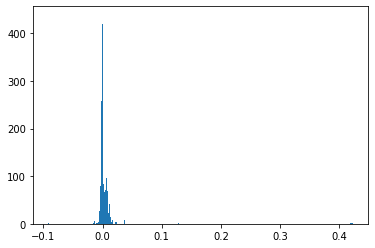

In [58]:
_ = plt.hist(ig_gcn_bert_values[0], bins='auto')
plt.show()

In [20]:
(ig_gcn_bert_values[0]**2).sum(), (shap_gcn_bert_values[0]**2).sum()

(1.0, 0.0015436368818022572)

In [13]:
random.seed(0)
idx = np.arange(len(dataset))
random.shuffle(idx)

train_len = 1889
val_len = 270
test_len = 540
nb_word = 25297

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)
    
def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return test_idx[x - val_len - train_len]

In [81]:
top_n_interpret = 5
top_ig_gcn_bert_values = np.argpartition(ig_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_ig_gcn_bert_values = np.vectorize(map_to_idx)(top_ig_gcn_bert_values)
top_shap_gcn_bert_values = np.argpartition(shap_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_bert_values = np.vectorize(map_to_idx)(top_shap_gcn_bert_values)

In [15]:
first_order_adj = adj @ adj
first_order_adj = first_order_adj.toarray()

In [16]:
top_n_input = 10
top_input_test_rel_nodes = np.argpartition(first_order_adj[test_mask][:, doc_mask], -top_n_input)[:, -top_n_input:]
top_input_test_rel_nodes = np.vectorize(map_to_idx)(top_input_test_rel_nodes)
top_input_test_rel_nodes.max(), top_input_test_rel_nodes.shape

(2688, (540, 10))

In [82]:
s = 0
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

s = 0
for a, b in zip(top_input_test_rel_nodes, top_shap_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

1780
1788


In [83]:
input_only, interpret_only, both = list(), list(), list()
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    input_only.append(np.setdiff1d(a, b))
    interpret_only.append(np.setdiff1d(b, a))
    both.append(np.intersect1d(b, a))
compare_df = pd.DataFrame({"interpret only": interpret_only, "input only": input_only, "both": both}, index=test_idx)
compare_df

,interpret only,input only,both
2298,[],"[2295, 2296, 2297, 2298, 2299]","[2291, 2292, 2293, 2294, 2300]"
2130,[],"[22, 23, 24, 2134, 2136]","[2130, 2131, 2132, 2133, 2135]"
2559,[],"[2560, 2561, 2562, 2564, 2565]","[2556, 2557, 2558, 2559, 2563]"
1046,"[1354, 1355, 1594]","[1044, 1045, 1047, 1048, 1049, 1050, 1051, 1053]","[1046, 1052]"
1991,"[109, 326, 1391, 1829, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[]
...,...,...,...
2094,"[1334, 1335, 1337]","[550, 551, 1600, 1601, 1602, 1603, 2092, 2093]","[2094, 2095]"
1060,[],"[1057, 1058, 1061, 1911, 1912]","[1054, 1055, 1056, 1059, 1060]"
165,"[85, 86, 87, 88, 2553]","[161, 162, 163, 164, 165, 166, 1133, 1136, 113...",[]
1722,[1727],"[1721, 1722, 1723, 1730, 1731, 1733]","[1726, 1729, 1735, 1736]"


In [84]:
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]

<AxesSubplot:>

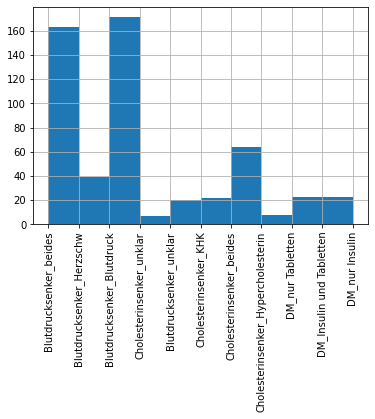

In [85]:
compare_df["data label"].hist(xrot=90)

In [21]:
from model import BertGCN
from ignite.engine import Engine, Events
from ignite.utils import setup_logger
import dgl
import datetime
import torch.utils.data as Data
from ignite.metrics import Accuracy, ClassificationReport, Loss, Precision, Recall
from ignite.handlers.stores import EpochOutputStore
from metrics import SklearnClassificationReport

BATCHSIZE = 8


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = BertGCN(
    nb_class=nb_class,
    pretrained_model=PRETRAINEDMODEL,
    mix_factor=args.mixfactor,
    gcn_layers=2,
    n_hidden=200,
    dropout=0.5,
)

model = model.to(device)
model = model.eval()

# document mask used for update feature
doc_mask = train_mask + val_mask + test_mask

input_ids = torch.cat(
    [
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[train_idx]])),
        torch.zeros((nb_word, tokenizer.model_max_length), dtype=torch.long),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[val_idx]])),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[test_idx]])),
    ]
)

assert np.array_equal(y[:nb_train], dataset.labels[train_idx])
assert np.array_equal(y[nb_train + nb_word : nb_train + nb_word + nb_val], dataset.labels[val_idx])

assert np.array_equal(y[-nb_test:], dataset.labels[test_idx])

adj_norm = normalize_adj(adj + sp.eye(adj.shape[0]))


test_idx_dataset = Data.TensorDataset(torch.arange(nb_node - nb_test, nb_node, dtype=torch.long))

idx_loader_test = Data.DataLoader(test_idx_dataset, batch_size=BATCHSIZE)

graph = dgl.from_scipy(adj_norm.astype("float32"), eweight_name="edge_weight")
graph.ndata["input_ids"] = input_ids
graph.ndata["label"], graph.ndata["train"], graph.ndata["val"], graph.ndata["test"] = (
    torch.LongTensor(y),
    torch.FloatTensor(train_mask),
    torch.FloatTensor(val_mask),
    torch.FloatTensor(test_mask),
)
graph.ndata["label_train"] = torch.LongTensor(y_train)
graph.ndata["cls_feats"] = torch.zeros((nb_node, model.feat_dim))

def update_feature():
    global graph, model
    dataloader = Data.DataLoader(Data.TensorDataset(graph.ndata["input_ids"][doc_mask]), batch_size=64)
    with torch.no_grad():
        model.eval()
        cls_list = []
        logging.info("Udating features...")
        for batch in dataloader:
            input_ids = [x.to(device) for x in batch][0]
            output = model.bert_model(input_ids=input_ids)[0][:, 0]
            cls_list.append(output.cpu())
        cls_feat = torch.cat(cls_list, axis=0)
    graph = graph.to("cpu")
    graph.ndata["cls_feats"][doc_mask] = cls_feat
    
logging.info(f"Loading best gcn model from {GCNPATH} saved on {datetime.datetime.fromtimestamp(GCNPATH.stat().st_ctime)}")
model.load_state_dict(torch.load(GCNPATH, map_location="cpu"))

update_feature()

def eval_step(engine, batch):
    global model, graph
    with torch.no_grad():
        model.eval()
        model = model.to(device)
        graph = graph.to(device)
        (idx,) = [x.to(device) for x in batch]
        y_pred = model(graph, idx)
        y_true = graph.ndata["label"][idx]
        return y_pred, y_true

test_evaluator = Engine(eval_step)
test_evaluator.logger = setup_logger("test evaluator", level=30)

precision = Precision(average=False)
recall = Recall(average=False)
F1 = (precision * recall * 2 / (precision + recall)).mean()
criterion = torch.nn.CrossEntropyLoss()

metrics = {
    "accuracy": Accuracy(),
    "f1": F1,
    "nll": Loss(criterion),
    "cr": SklearnClassificationReport(target_names=dataset.LE.classes_),
    "eos": EpochOutputStore()
}

for n, f in metrics.items():
    f.attach(test_evaluator, n)
    
test_evaluator.run(idx_loader_test)
metrics = test_evaluator.state.metrics

preds = np.vectorize(lambda x: dataset.LE.classes_[x])(np.concatenate([np.argmax(x[0].cpu().numpy(), axis=-1) for x in test_evaluator.state.eos])).tolist()#.ravel()).tolist()

Using backend: pytorch
Some weights of BertModel were not initialized from the model checkpoint at /prj/doctoral_letters/PETGUI/med_bert_local and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [86]:
compare_df["prediction"] = preds
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]
compare_df["correct pred"] = list(map(int, compare_df["prediction"] == compare_df["data label"]))
compare_df["arznei"] = [re.findall("Arznei (.+?) &", dataset.texts[x])[0] for x in compare_df.index]
compare_df["interpret labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["interpret only"]]
compare_df["interpret arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["interpret only"]]
compare_df["input labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in compare_df["input only"]]
compare_df["input arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in compare_df["input only"]]
compare_df["label overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["input labels"])]
compare_df["arznei overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["input arznei"])]
compare_df["interpret label equals data label"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret labels"], compare_df["data label"])]
compare_df["interpret arznei equals data arznei"] = [sum([xx==y for xx in x])/3 for x, y in zip(compare_df["interpret arznei"], compare_df["arznei"])]
compare_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,540.000000,540.000000,540.000000,540.000000,540.000000
mean,0.937037,0.166667,0.096914,0.219136,0.041975
std,0.243122,0.341278,0.236511,0.360266,0.127966
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.333333,0.000000,0.333333,0.000000
max,1.000000,1.666667,1.666667,1.666667,0.666667


In [87]:
compare_df

,interpret only,input only,both,data label,prediction,correct pred,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
2298,[],"[2295, 2296, 2297, 2298, 2299]","[2291, 2292, 2293, 2294, 2300]",Blutdrucksenker_beides,DM_nur Tabletten,0,Amilorid,[],[],"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Norvasc, Amlodipin, Simvastatin, Amilorid, Ra...",0.000000,0.000000,0.000000,0.000000
2130,[],"[22, 23, 24, 2134, 2136]","[2130, 2131, 2132, 2133, 2135]",Blutdrucksenker_Herzschw,Blutdrucksenker_Herzschw,1,Ramipril,[],[],"[Blutdrucksenker_Herzschw, Blutdrucksenker_Her...","[Dilatrend, Carvedilol, Ramipril, Xipamid, Epl...",0.000000,0.000000,0.000000,0.000000
2559,[],"[2560, 2561, 2562, 2564, 2565]","[2556, 2557, 2558, 2559, 2563]",Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck,1,Ramipril,[],[],"[Cholesterinsenker_beides, Cholesterinsenker_b...","[Sortis, Atorvastatin, Torem, Metformin, Insulin]",0.000000,0.000000,0.000000,0.000000
1046,"[1354, 1355, 1594]","[1044, 1045, 1047, 1048, 1049, 1050, 1051, 1053]","[1046, 1052]",Cholesterinsenker_unklar,Cholesterinsenker_KHK,0,Atorvastatin,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Delix, Ramipril, Beloc]","[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Bisoprolol, Ramipril, HCT, Bisoprolol, Ramipr...",0.000000,0.333333,0.000000,0.000000
1991,"[109, 326, 1391, 1829, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[],Blutdrucksenker_unklar,Blutdrucksenker_unklar,1,Metoprololsuccinat,"[DM_nur Tabletten, DM_nur Insulin, Cholesterin...","[Amaryl, Insulin, Ezetrol, Torasemid, Torasemid]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Torasemid, Torasemid, DelixUNK, Atorvastatin-...",0.333333,0.666667,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,"[1334, 1335, 1337]","[550, 551, 1600, 1601, 1602, 1603, 2092, 2093]","[2094, 2095]",Blutdrucksenker_Blutdruck,Blutdrucksenker_beides,0,Amlodipin,"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Bisoprolol, Amlodipin, Ramipril]","[Blutdrucksenker_Herzschw, Blutdrucksenker_Her...","[Candesartan, Torasemid, Belok, Delix, Pravast...",0.000000,0.000000,1.000000,0.333333
1060,[],"[1057, 1058, 1061, 1911, 1912]","[1054, 1055, 1056, 1059, 1060]",Blutdrucksenker_beides,Blutdrucksenker_beides,1,Furosemid,[],[],"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Aldactone, Spironolacton, Atorvastatin, Delix...",0.000000,0.000000,0.000000,0.000000
165,"[85, 86, 87, 88, 2553]","[161, 162, 163, 164, 165, 166, 1133, 1136, 113...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Sortis,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Concor, Bisoprolol, Delix, Ramipril, Amaryl]","[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Delix, Ramipril, Norvasc, Amlodipin, Sortis, ...",0.000000,1.000000,0.000000,0.000000
1722,[1727],"[1721, 1722, 1723, 1730, 1731, 1733]","[1726, 1729, 1735, 1736]",Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck,1,Carvedilol,[Blutdrucksenker_Blutdruck],[Delix],"[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Dilatrend, Carvedilol, Zocor, Hydrochlorothia...",0.333333,0.000000,0.333333,0.000000


In [88]:
if not os.path.exists("outputs/csvs/"):
    os.mkdir("outputs/csvs/")
compare_df.to_csv("outputs/csvs/compare_df.csv")

In [89]:
unklar_df = compare_df[compare_df["data label"].str.contains("unklar")]
unklar_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,27.000000,27.000000,27.000000,27.000000,27.000000
mean,0.777778,0.407407,0.432099,0.148148,0.086420
std,0.423659,0.608581,0.304030,0.350010,0.148859
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.333333,0.000000,0.000000
50%,1.000000,0.000000,0.333333,0.000000,0.000000
75%,1.000000,1.000000,0.666667,0.000000,0.166667
max,1.000000,1.666667,1.333333,1.333333,0.333333


In [90]:
unklar_df[unklar_df["data label"] == "Cholesterinsenker_unklar"].prediction.unique()

array(['Cholesterinsenker_KHK', 'Cholesterinsenker_unklar',
       'Cholesterinsenker_Hypercholesterin'], dtype=object)

In [91]:
unklar_df[unklar_df["data label"] == "Cholesterinsenker_unklar"].describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,7.000000,7.0,7.000000,7.000000,7.000000
mean,0.285714,0.0,0.333333,0.571429,0.142857
std,0.487950,0.0,0.272166,0.498675,0.178174
min,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.000000,0.0,0.166667,0.166667,0.000000
50%,0.000000,0.0,0.333333,0.666667,0.000000
75%,0.500000,0.0,0.500000,0.833333,0.333333
max,1.000000,0.0,0.666667,1.333333,0.333333


In [92]:
unklar_df[unklar_df["data label"] == "Blutdrucksenker_unklar"].describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,20.000000,20.000000,20.000000,20.0,20.000000
mean,0.950000,0.550000,0.466667,0.0,0.066667
std,0.223607,0.651359,0.313442,0.0,0.136797
min,0.000000,0.000000,0.000000,0.0,0.000000
25%,1.000000,0.000000,0.333333,0.0,0.000000
50%,1.000000,0.166667,0.333333,0.0,0.000000
75%,1.000000,1.333333,0.666667,0.0,0.000000
max,1.000000,1.666667,1.333333,0.0,0.333333


In [93]:
unklar_df[unklar_df["data label"] == "Blutdrucksenker_unklar"].prediction.unique()

array(['Blutdrucksenker_unklar', 'Blutdrucksenker_Blutdruck'],
      dtype=object)

In [94]:
diff_df = compare_df[compare_df['interpret only'].map(len) == top_n_interpret]
diff_df.head()

,interpret only,input only,both,data label,prediction,correct pred,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
1991,"[109, 326, 1391, 1829, 1837]","[75, 76, 79, 80, 82, 83, 84, 1990, 1991, 1992]",[],Blutdrucksenker_unklar,Blutdrucksenker_unklar,1,Metoprololsuccinat,"[DM_nur Tabletten, DM_nur Insulin, Cholesterin...","[Amaryl, Insulin, Ezetrol, Torasemid, Torasemid]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Torasemid, Torasemid, DelixUNK, Atorvastatin-...",0.333333,0.666667,0.0,0.000000
1865,"[945, 1739, 1740, 1741, 1742]","[1862, 1863, 1864, 1865, 1866, 1867, 1868, 186...",[],Blutdrucksenker_unklar,Blutdrucksenker_unklar,1,Ramipril,"[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Bisoprolol, Beloc, Metoprololsucc, Ramipril, ...","[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Torem, Beloc, Metoprololsuccinat, Ramipril, A...",0.000000,0.666667,0.0,0.333333
1521,"[632, 1893, 1898, 1991, 2281]","[139, 141, 1519, 1520, 1521, 1522, 1523, 1524,...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Ezetimib,"[DM_nur Insulin, DM_nur Insulin, DM_nur Insuli...","[Insulin, Actrapid, Actrapid, Metoprololsuccin...","[Cholesterinsenker_beides, Cholesterinsenker_b...","[Simvastatin, Simvastatin, Ramipril, Inegy, Ez...",0.000000,0.000000,0.0,0.000000
1203,"[11, 325, 326, 1291, 1372]","[1200, 1201, 1202, 1203, 1204, 1205, 1206, 120...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Atorvastatin,"[DM_nur Insulin, DM_nur Insulin, DM_nur Insuli...","[Actraphane, Actrapid, Insulin, Schnell, Humalog]","[Blutdrucksenker_Blutdruck, Blutdrucksenker_Bl...","[Bisoprolol, Candesartan, Torasemid, Atorvasta...",0.000000,0.000000,0.0,0.000000
454,"[40, 1354, 1355, 1356, 1372]","[451, 452, 453, 454, 455, 456, 457, 458, 1906,...",[],Cholesterinsenker_beides,Cholesterinsenker_beides,1,Simvastatin,"[Cholesterinsenker_KHK, Blutdrucksenker_unklar...","[Atorvastatin, Delix, Ramipril, Norvasc, Humalog]","[Blutdrucksenker_beides, Blutdrucksenker_beide...","[Metropolol, Ramipril, Torasemid, Simvastatin,...",0.000000,0.333333,0.0,0.000000


In [95]:
diff_df.describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,80.000000,80.000000,80.000000,80.000000,80.000000
mean,0.887500,0.295833,0.320833,0.137500,0.045833
std,0.317974,0.538252,0.376690,0.429875,0.137731
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.333333,0.000000,0.000000
75%,1.000000,0.333333,0.666667,0.000000,0.000000
max,1.000000,1.666667,1.666667,1.666667,0.666667


In [96]:
diff_df[diff_df["data label"].str.contains("unklar")].describe()

,correct pred,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data arznei
count,20.000000,20.000000,20.000000,20.0,20.000000
mean,0.950000,0.550000,0.466667,0.0,0.066667
std,0.223607,0.651359,0.313442,0.0,0.136797
min,0.000000,0.000000,0.000000,0.0,0.000000
25%,1.000000,0.000000,0.333333,0.0,0.000000
50%,1.000000,0.166667,0.333333,0.0,0.000000
75%,1.000000,1.333333,0.666667,0.0,0.000000
max,1.000000,1.666667,1.333333,0.0,0.333333


<AxesSubplot:>

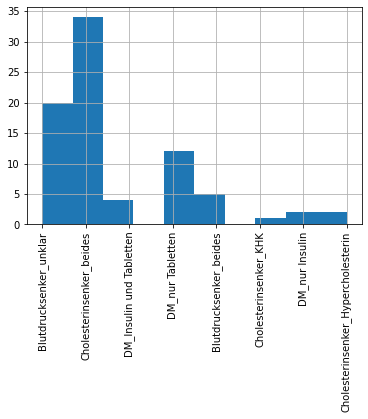

In [97]:
diff_df["data label"].hist(xrot=90)

In [98]:
random.seed(0)
n_letters_per = 3

sample_df = diff_df[diff_df["data label"] != "Blutdrucksenker_unklar"].sample(3 * n_letters_per)
#sample_df = diff_df[diff_df["data label"] != "Blutdrucksenker_unklar"].groupby('data label', as_index=True).apply(lambda s: s.sample(min(len(s), 2)))

#sample_df.index = sample_df.index.droplevel()

sample_df["data label"]

490             DM_nur Tabletten
1678    DM_Insulin und Tabletten
2333            DM_nur Tabletten
1941    Cholesterinsenker_beides
1520    Cholesterinsenker_beides
905     Cholesterinsenker_beides
2465            DM_nur Tabletten
172     Cholesterinsenker_beides
165     Cholesterinsenker_beides
Name: data label, dtype: object

In [99]:
letter_dir = "outputs/letters/"   

if not os.path.exists(letter_dir):
    os.mkdir(letter_dir)

c = 0

for i, x in enumerate(sample_df.index):
    if i % n_letters_per == 0:
        c += 1
        
    path = f"{letter_dir}/{c}"
    
    if not os.path.exists(path):
        os.mkdir(path)
        
    letter_path = f"{path}/{x}"
    
    if not os.path.exists(letter_path):
        os.mkdir(letter_path)
    
    with open(f"{letter_path}/{sample_df.loc[x]['data label']}-{sample_df.loc[x]['prediction']}.txt", 'w') as f:
        print(dataset.texts[x], file=f)
    prev = None
    for y in sample_df.loc[x]["interpret only"]:
        ass_path = f"{letter_path}/{y}"

        arznei = re.findall("Arznei (.+?) &", dataset.texts[y])[0]
        cur = dataset.texts[y]
        start = re.search("Arznei .+? &", cur).span()[1]
        if prev is None or prev != cur[start:]:
            if not os.path.exists(ass_path):
                os.mkdir(ass_path)      
        
            with open(f"{ass_path}/{dataset.LE.classes_[dataset[y]['labels']]}.txt", 'w') as f:
                print(cur[start:].strip(), file=f)
        prev = cur[start:]